## Bibliotecas necessárias

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, random, warnings, sklearn
import plotly.express as px,joblib
import shap

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from datetime import datetime
from io import BytesIO

In [10]:
# Configurações de exibição do pandas
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## Funções

In [11]:
def normalize_columns(df):
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]
    return out

def isFileExists(file_path):
    if os.path.exists(file_path):
        return True
    else:
        print("Arquivo não encontrado:", file_path)
        return False

def eval_model(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    f1 = 2*(precision*recall)/(precision+recall+1e-9)
    best_threshold = thresholds[np.argmax(f1)]

    pred = (proba >= best_threshold).astype(int)

    roc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    print(f'\n=== {name} ===')
    print('ROC-AUC:', round(roc, 4))
    print('PR-AUC :', round(ap, 4))
    print(f'\nConfusion matrix:\n', confusion_matrix(y_test, pred))
    print(f'\nReport:\n', classification_report(y_test, pred, digits=3))

    # Curvas
    fpr, tpr, _ = roc_curve(y_test, proba)
    pr, rc, _ = precision_recall_curve(y_test, proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f'ROC - {name}')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.plot(rc, pr)
    plt.title(f'Precision-Recall - {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()

## Carregamento dos dados

In [12]:
datasetFile = "data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

if not isFileExists(datasetFile): exit()

# Ler todas as abas
xls = pd.ExcelFile(datasetFile)
print('Sheets:', xls.sheet_names)

dfs = {}
for sh in xls.sheet_names:
    dfs[sh] = xls.parse(sh)
    print(sh, dfs[sh].shape)

# Preview
for sh, df_ in dfs.items():
    print('===', sh, '===')
    display(df_.head(3))

Sheets: ['PEDE2022', 'PEDE2023', 'PEDE2024']
PEDE2022 (860, 42)
PEDE2023 (1014, 48)
PEDE2024 (1156, 50)
=== PEDE2022 ===


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...


=== PEDE2023 ===


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.5,10.0,8.13,8.4375,NaN,9.6,9.8,9.4,NaN,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.5,9.1,8.14,7.5000,NaN,8.9,8.5,9.2,NaN,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.0,7.6,3.14,5.9375,NaN,6.3,7.0,5.5,NaN,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


=== PEDE2024 ===


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,8.666667,6.26,5.625,NaN,8.0,10.0,6.0,NaN,NaN,NaN,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.333333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.083333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando


## União das bases

In [13]:
p22 = normalize_columns(dfs['PEDE2022']).copy()
p23 = normalize_columns(dfs['PEDE2023']).copy()
p24 = normalize_columns(dfs['PEDE2024']).copy()

p22['ano_ref'] = 2022
p23['ano_ref'] = 2023
p24['ano_ref'] = 2024

# Padronizar alguns nomes comuns
rename_22 = {
    'Nome': 'Nome_Anon',
    'Ano nasc': 'Ano_Nasc',
    'Idade 22': 'Idade',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 22': 'INDE',
}
rename_23 = {
    'Nome Anonimizado': 'Nome_Anon',
    'Data de Nasc': 'Data_Nasc',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 23': 'INDE',
}
rename_24 = {
    'Nome Anonimizado': 'Nome_Anon',
    'Data de Nasc': 'Data_Nasc',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 2024': 'INDE',
}

p22 = p22.rename(columns=rename_22)
p23 = p23.rename(columns=rename_23)
p24 = p24.rename(columns=rename_24)

# Padronizar notas de disciplinas
p22 = p22.rename(columns={'Matem': 'Mat', 'Portug': 'Por', 'Inglês': 'Ing'})

# Garantir colunas-chave existam
for df_ in (p22, p23, p24):
    for col in ['RA', 'Fase', 'Turma', 'Gênero', 'Ano ingresso', 'Instituicao_Ensino', 'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Defasagem', 'Fase Ideal', 'IPP']:
        if col not in df_.columns:
            df_[col] = np.nan

# Unir
base = pd.concat([p22, p23, p24], ignore_index=True)

# Ajustes finais de tipos
base['RA'] = base['RA'].astype(str)
base['ano_ref'] = base['ano_ref'].astype(int)

# Datas (quando existir)
if 'Data_Nasc' in base.columns:
    base['Data_Nasc'] = pd.to_datetime(base['Data_Nasc'], errors='coerce')

# Padronizar genero (tem "Menina"/"Feminino" etc)
base['Gênero'] = base['Gênero'].astype(str).str.strip().replace(
    {'Feminino': 'Menina', 'Masculino': 'Menino'})

print('Base unificada:', base.shape)
display(base.head())

Base unificada: (3030, 59)


,RA,Fase,Turma,Nome_Anon,Ano_Nasc,Idade,Gênero,Ano ingresso,Instituicao_Ensino,Pedra 20,Pedra 21,Pedra 22,INDE,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ano_ref,Defasagem,Fase Ideal,IPP,INDE 2023,Pedra 2023,Data_Nasc,Pedra 23,INDE 22,Destaque IPV.1,Pedra 2024,INDE 23,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.8,4.5,5.6,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.9,8.6,5.6,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pré-processamento dos dados

In [14]:
# Nulos
nulls = (base.isna().mean().sort_values(ascending=False) * 100).round(1)
display(nulls.to_frame('% nulos').head(25))

# Duplicados
dups = base.duplicated(subset=['RA', 'ano_ref']).sum()
print('Duplicados (RA, ano_ref):', dups)

# Ranges basicos
for c in ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Mat', 'Por', 'Ing']:
    if c in base.columns:
        s = pd.to_numeric(base[c], errors='coerce')
        print(c, 'min=', np.nanmin(s.values), 'max=', np.nanmax(s.values))

,% nulos
Destaque IPV.1,100.0
Avaliador6,99.8
Avaliador5,95.1
Rec Av4,90.2
Pedra 23,77.2
INDE 23,77.2
Pedra 20,75.1
Cg,71.6
Ct,71.6
Rec Av3,71.6


Duplicados (RA, ano_ref): 0
INDE min= 3.032 max= 9.531325
IAA min= 0.0 max= 10.002
IEG min= 0.0 max= 10.0
IPS min= 2.5 max= 10.0
IDA min= 0.0 max= 10.0
IPV min= 2.5 max= 10.01
IAN min= 2.5 max= 10.0
Mat min= 0.0 max= 10.0
Por min= 0.0 max= 10.0
Ing min= 0.0 max= 10.0


## Feature Enginnering  

In [15]:
# Definir target de risco (ajuste os cortes)

tmp = base.copy()

tmp['Defasagem_num'] = pd.to_numeric(
    tmp['Defasagemagem'] if 'Defasagemagem' in tmp.columns else tmp.get('Defasagem'), errors='coerce')
tmp['IAN_num'] = pd.to_numeric(tmp['IAN'], errors='coerce')

tmp = tmp.sort_values(['RA', 'ano_ref'])

tmp['IAN_futuro'] = tmp.groupby('RA')['IAN_num'].shift(-1)


# Default: risco se defasagem negativa relevante OU IAN alto
risk_defas = tmp['Defasagem_num'].le(-1)
risk_ian = tmp['IAN_num'].ge(7)

tmp['risco'] = (tmp['IAN_futuro'] >= 7).astype(int)

tmp = tmp.dropna(subset=['IAN_futuro'])

target_col = tmp['risco'].name

assert target_col is not None, "Coluna alvo não encontrada"

print(tmp['risco'].value_counts(dropna=False))

feature_cols = [
    'ano_ref', 'Fase', 'Turma', 'Gênero', 'Ano ingresso', 'Instituicao_Ensino',
    'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'INDE', 'IAN',
    'Mat', 'Por', 'Ing', 'Idade',
    'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Pedra 2023', 'Pedra 2024',
    'Escola', 'Ativo/ Inativo'
]

# Manter só as que existem
feature_cols = [c for c in feature_cols if c in tmp.columns]

X = tmp[feature_cols].copy()
y = tmp['risco'].copy()

# Lista de colunas que deveriam ser numéricas
potential_num_cols = ['ano_ref', 'Ano ingresso', 'IAA', 'IEG', 'IPS',
                      'IPP', 'IDA', 'IPV', 'INDE', 'IAN', 'Mat', 'Por', 'Ing', 'Idade']

# Converter colunas numéricas para o tipo correto, coercing erros para NaN
# Isso resolve o problema de strings como 'INCLUIR' em colunas numéricas
num_cols = []
for col in potential_num_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        num_cols.append(col)

# Categorical columns são as que sobram de feature_cols
cat_cols = [c for c in feature_cols if c not in num_cols]

# Converter explicitamente colunas categóricas para string para evitar TypeErrors no OneHotEncoder
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)

print('Num:', num_cols)
print('Cat:', cat_cols)

tmp.to_csv('data/dados_tratados.csv',
          sep=';',
          index=False,
          encoding='utf-8-sig')

risco
1    694
0    675
Name: count, dtype: int64
Num: ['ano_ref', 'Ano ingresso', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'INDE', 'IAN', 'Mat', 'Por', 'Ing', 'Idade']
Cat: ['Fase', 'Turma', 'Gênero', 'Instituicao_Ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Pedra 2023', 'Pedra 2024', 'Escola', 'Ativo/ Inativo']


## Treinamento do modelo

In [16]:
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
pathNameArtifacts = "model"

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=tmp['RA']))

# Split
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Preprocess
numeric_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols)
    ],
    remainder='drop'
)

# Modelos
logreg = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

pipe_logreg = Pipeline(steps=[('prep', preprocess), ('model', logreg)])
pipe_rf = Pipeline(steps=[('prep', preprocess), ('model', rf)])

# Treinar
pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Salvar informações das features
with open(os.path.join(pathNameArtifacts, "feature_info.json"), "w", encoding="utf-8") as f:
    json.dump({"num_cols": num_cols, "cat_cols": cat_cols, "target": target_col,
               "classes": sorted(y.unique().tolist())}, f, ensure_ascii=False, indent=2)

print('Treino ok')

Treino ok


## Carregar Modelo escolhido


=== LogReg ===
ROC-AUC: 0.8939
PR-AUC : 0.9065

Confusion matrix:
 [[106  27]
 [ 23 114]]

Report:
               precision    recall  f1-score   support

           0      0.822     0.797     0.809       133
           1      0.809     0.832     0.820       137

    accuracy                          0.815       270
   macro avg      0.815     0.815     0.815       270
weighted avg      0.815     0.815     0.815       270



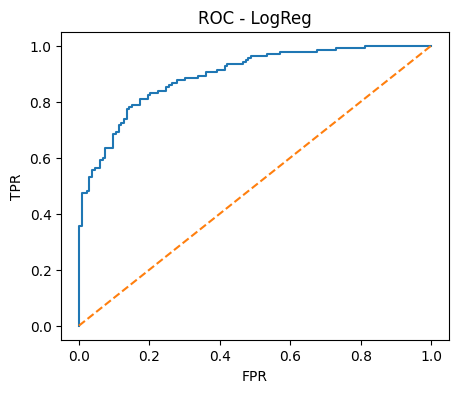

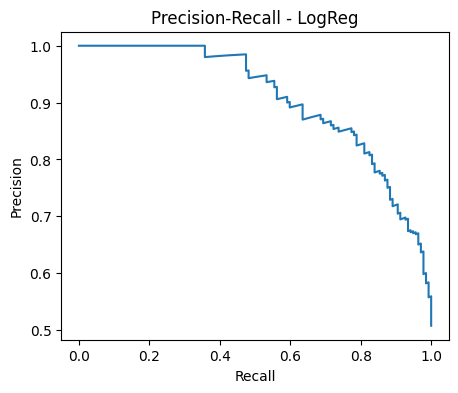


=== RandomForest ===
ROC-AUC: 0.888
PR-AUC : 0.8947

Confusion matrix:
 [[ 95  38]
 [ 15 122]]

Report:
               precision    recall  f1-score   support

           0      0.864     0.714     0.782       133
           1      0.762     0.891     0.822       137

    accuracy                          0.804       270
   macro avg      0.813     0.802     0.802       270
weighted avg      0.812     0.804     0.802       270



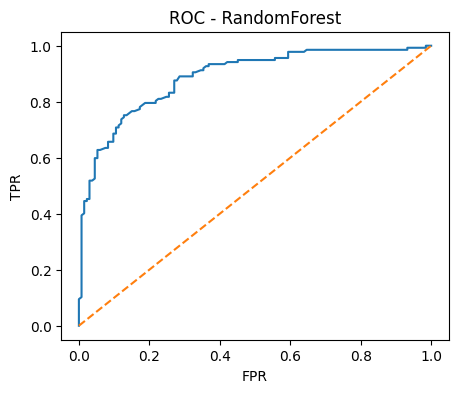

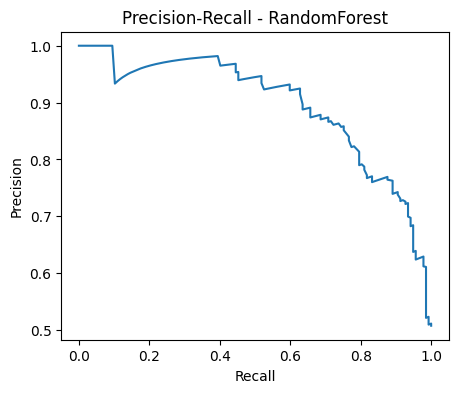

Modelo escolhido salvo em: model\best_model_rf.joblib


In [17]:
eval_model('LogReg', pipe_logreg, X_test, y_test)
eval_model('RandomForest', pipe_rf, X_test, y_test)

best_model = pipe_rf


with open(os.path.join(pathNameArtifacts, "feature_info.json"), "r", encoding="utf-8") as f:
    finfo = json.load(f)

MODEL_OUT = Path('model/best_model_{best_name}.joblib'.format(best_name='rf'))
joblib.dump(best_model, MODEL_OUT)

num_cols = finfo.get("num_cols", [])
cat_cols = finfo.get("cat_cols", [])
tgt = finfo.get("target")

print('Modelo escolhido salvo em:', MODEL_OUT)

## Métricas

In [18]:
# Avaliação no conjunto de teste
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

## Análises

,ano_ref,Fase,IAN
0,2022,0,6.802632
1,2022,1,5.742188
2,2022,2,6.403226
3,2022,3,6.993243
4,2022,4,6.480263


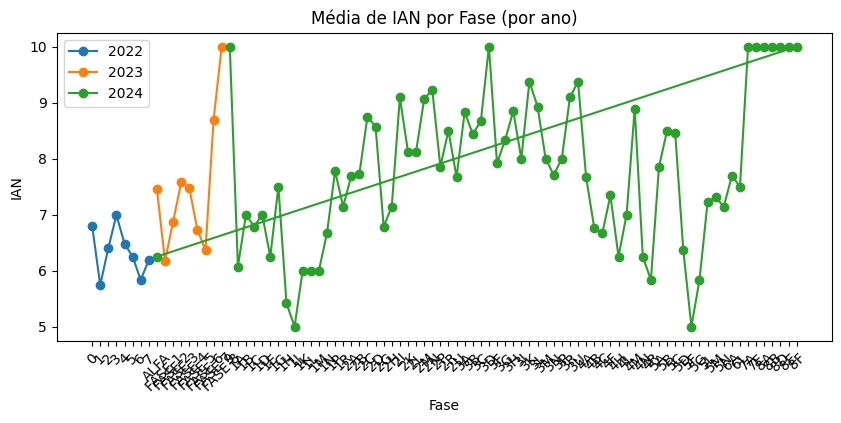

In [19]:
metric = 'IAN'  # troque para 'IDA', 'INDE', etc.

tmp = base.copy()
tmp[metric] = pd.to_numeric(tmp[metric], errors='coerce')

grp = tmp.groupby(['ano_ref', 'Fase'])[metric].mean().reset_index()
display(grp.head())

# Plot simples
plt.figure(figsize=(10, 4))
for yr, g in grp.groupby('ano_ref'):
    plt.plot(g['Fase'].astype(str), g[metric], marker='o', label=str(yr))
plt.title(f'Média de {metric} por Fase (por ano)')
plt.xlabel('Fase')
plt.ylabel(metric)
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Métricas

In [20]:
print("MÉTRICAS")

print('Acurácia no teste:', round(acc, 4))

MÉTRICAS
Acurácia no teste: 0.7963


# Gera Relatórios

In [21]:
print("RELATÓRIOS")

html_path="reports/Relatorio_TechChallenge_Passos.html"; md_path="reports/Relatorio_TechChallenge_Passos.md"
key_insights=[f"Tamanho da base: {len(base)}", f"Acurácia (estimada aqui): {acc:.4f}" if acc is not None else "Acurácia não recalculada aqui", "Principais variáveis: BMI, hábitos (FAVC, CAEC, CH2O, FAF), histórico familiar, sexo, idade"]
html="<!DOCTYPE html><html lang='pt-br'><head><meta charset='utf-8'/><title>Relatório — Tech Challenge Passos</title><style>body{font-family:Arial;margin:2rem}h1,h2{color:#222}</style></head><body><h1>Relatório — Tech Challenge (Passos)</h1><p><strong>Data:</strong> "+datetime.now().strftime("%Y-%m-%d %H:%M:%S")+"</p><h2>Resumo</h2><p>Modelo multi-classe para níveis de obesidade; pipeline completa; deploy via Streamlit.</p><h2>Indicadores</h2><ul>"+("".join([f"<li>{it}</li>" for it in key_insights]))+"</ul><h2>Insights</h2><ul><li>BMI separa parcialmente as classes; hábitos deslocam probabilidade entre faixas vizinhas.</li><li>Consumo de água (CH2O) e atividade física (FAF) correlacionam com classes mais baixas.</li><li>Histórico familiar e consumo calórico (FAVC) elevam risco.</li></ul></body></html>"

open(html_path,"w",encoding="utf-8").write(html)
open(md_path,"w",encoding="utf-8").write("# Relatório — Tech Challenge (Passos)\n"+"\n".join([f"- {it}" for it in key_insights]))

print("Gerado:", html_path, "|", md_path)

RELATÓRIOS
Gerado: reports/Relatorio_TechChallenge_Passos.html | reports/Relatorio_TechChallenge_Passos.md
